In [1]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")
print(f"Does it exist? {os.path.exists(src_path)}")

import numpy as np
import matplotlib.pyplot as plt
from multiproposal.data.gp_regression import generate_gp_regression_data
from multiproposal.problems.gp_regression import GaussianProcessRegression
from multiproposal.algorithms.ess import ess_step
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size, compute_autocorrelation, integrated_autocorrelation_time, plot_ess_histograms

Repo root: /Users/guillers/Documents/GitHub/multiproposal
Added to path: /Users/guillers/Documents/GitHub/multiproposal/src
Does it exist? True


In [2]:
# Problem parameters
num_data = 200
D = 5
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 1000
burn_in = 500

seed = 0


In [3]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 200)
y shape: (200,)


In [4]:
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print("Initial log-likelihood:", problem.log_likelihood(x0))

Initial log-likelihood: -1794.5296365567697


In [5]:
rng_ess = np.random.default_rng(seed)

chain_ess = np.zeros((n_iters + 1, num_data))
chain_ess[0] = x0.copy()  # Initial state
intervals_ess = np.zeros(n_iters, dtype=int)    
x = x0.copy()

t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_ess, P1_ess = ess_step(x, problem, rng_ess)
    chain_ess[t + 1] = x
    intervals_ess[t] = nr_intervals_ess
t1 = time.time()
ess_time = t1 - t0
print(f"ESS sampling time: {ess_time:.2f} seconds")

ESS sampling time: 0.13 seconds


In [6]:
rng_mess = np.random.default_rng(seed)

M = 20
chain_mess = np.zeros((n_iters + 1, num_data))
chain_mess[0] = x0.copy()  # Initial state
intervals_mess = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Uniform transition matrix
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M)
    chain_mess[t + 1] = x
    intervals_mess[t] = nr_intervals_mess
t1 = time.time()
mess_time = t1 - t0
print(f"MESS sampling time: {mess_time:.2f} seconds")

MESS sampling time: 0.14 seconds


In [7]:
rng_mess = np.random.default_rng(seed)

chain_mess_ang = np.zeros((n_iters + 1, num_data))
chain_mess_ang[0] = x0.copy()  # Initial state
intervals_mess_ang = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Transition matrix with LP, angular distance
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M, 
                                              use_lp=True, distance_metric='angular', 
                                              lam=0.05)
    chain_mess_ang[t + 1] = x
    intervals_mess_ang[t] = nr_intervals_mess
t1 = time.time()
mess_ang_time = t1 - t0
print(f"MESS (angular) sampling time: {mess_ang_time:.2f} seconds")

MESS (angular) sampling time: 4.03 seconds


In [8]:
rng_mess = np.random.default_rng(seed)
M = 20
chain_mess_eucl = np.zeros((n_iters + 1, num_data))
chain_mess_eucl[0] = x0.copy()  # Initial state
intervals_mess_eucl = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Transition matrix with LP, euclidean distance
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M, 
                                              use_lp=True, distance_metric='euclidean', 
                                              lam=0.05)
    chain_mess_eucl[t + 1] = x
    intervals_mess_eucl[t] = nr_intervals_mess
t1 = time.time()
mess_eucl_time = t1 - t0
print(f"MESS (euclidean) sampling time: {mess_eucl_time:.2f} seconds")

MESS (euclidean) sampling time: 4.11 seconds


In [9]:
rng_mess = np.random.default_rng(seed)
M = 20
chain_mess_lam0 = np.zeros((n_iters + 1, num_data))
chain_mess_lam0[0] = x0.copy()  # Initial state
intervals_mess_lam0 = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Transition matrix with LP, angular distance, lambda=0
print("Testing MESS with lambda=0, printing transition matrix row every 10 iterations:\n")
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M, 
                                              use_lp=True, distance_metric='angular', 
                                              lam=0.0)
    chain_mess_lam0[t + 1] = x
    intervals_mess_lam0[t] = nr_intervals_mess
    
    # Print transition matrix row every 10 iterations
    if (t + 1) % 10 == 0 and P1_mess is not None:
        print(f"Iteration {t + 1}:")
        print(f"  Transition matrix row: {P1_mess}")
        print()
        
t1 = time.time()
mess_lam0_time = t1 - t0
print(f"MESS (lambda=0) sampling time: {mess_lam0_time:.2f} seconds")


Testing MESS with lambda=0, printing transition matrix row every 10 iterations:

Iteration 10:
  Transition matrix row: [[-0.  1.]
 [ 1. -0.]]

Iteration 20:
  Transition matrix row: [[-0. -0. -0. -0.  1. -0.]
 [-0. -0. -0.  1. -0. -0.]
 [-0. -0. -0. -0. -0.  1.]
 [ 1. -0. -0. -0. -0. -0.]
 [-0. -0.  1. -0. -0. -0.]
 [-0.  1. -0. -0. -0. -0.]]

Iteration 30:
  Transition matrix row: [[-0. -0. -0. -0. -0.  1. -0.]
 [-0. -0. -0. -0.  1. -0. -0.]
 [-0. -0. -0.  1. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -0.  1.]
 [-0.  1. -0. -0. -0. -0. -0.]
 [ 1. -0. -0. -0. -0. -0. -0.]
 [-0. -0.  1. -0. -0. -0. -0.]]

Iteration 40:
  Transition matrix row: [[-0. -0. -0. -0. -0.  1. -0. -0.]
 [-0. -0. -0. -0. -0. -0.  1. -0.]
 [-0. -0. -0. -0. -0. -0. -0.  1.]
 [-0. -0. -0. -0.  1. -0. -0. -0.]
 [-0.  1. -0. -0. -0. -0. -0. -0.]
 [ 1. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -0.  1. -0. -0. -0. -0. -0.]
 [-0. -0. -0.  1. -0. -0. -0. -0.]]

Iteration 50:
  Transition matrix row: [[-0.  1.]
 [ 1. -0.]]

Iteration 6

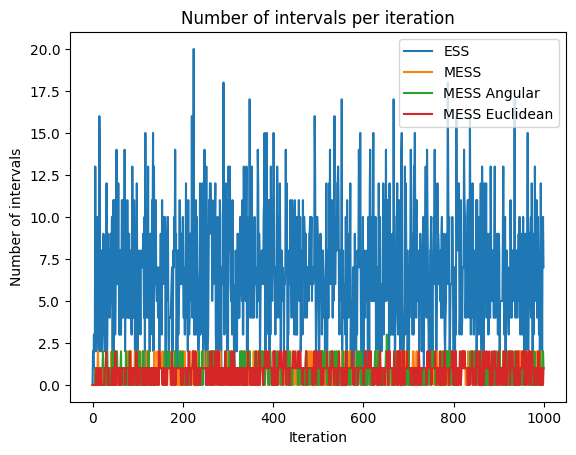

In [34]:
plt.plot(intervals_ess)
plt.plot(intervals_mess)
plt.plot(intervals_mess_ang)
plt.plot(intervals_mess_eucl)
plt.xlabel("Iteration")
plt.ylabel("Number of intervals")
plt.legend(["ESS", "MESS", "MESS Angular", "MESS Euclidean"])
plt.title("Number of intervals per iteration")
plt.show()

Text(0.5, 1.0, 'Log-likelihood trace')

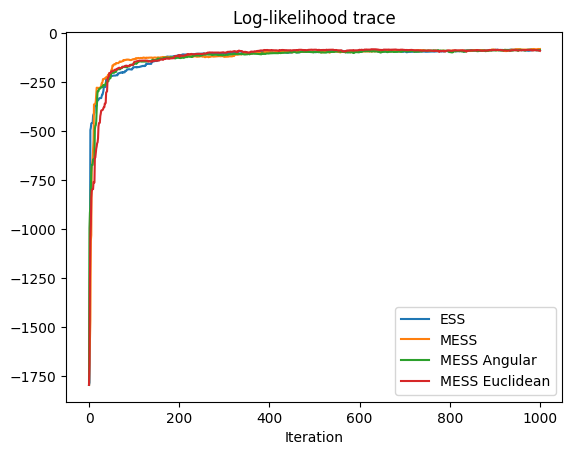

In [35]:
ll_ess = np.array([problem.log_likelihood(x) for x in chain_ess])
ll_mess = np.array([problem.log_likelihood(x) for x in chain_mess])
ll_mess_ang = np.array([problem.log_likelihood(x) for x in chain_mess_ang])
ll_mess_eucl = np.array([problem.log_likelihood(x) for x in chain_mess_eucl])

plt.plot(ll_ess, label="ESS")
plt.plot(ll_mess, label="MESS")
plt.plot(ll_mess_ang, label="MESS Angular")
plt.plot(ll_mess_eucl, label="MESS Euclidean")
plt.xlabel("Iteration")
plt.legend()
plt.title("Log-likelihood trace")

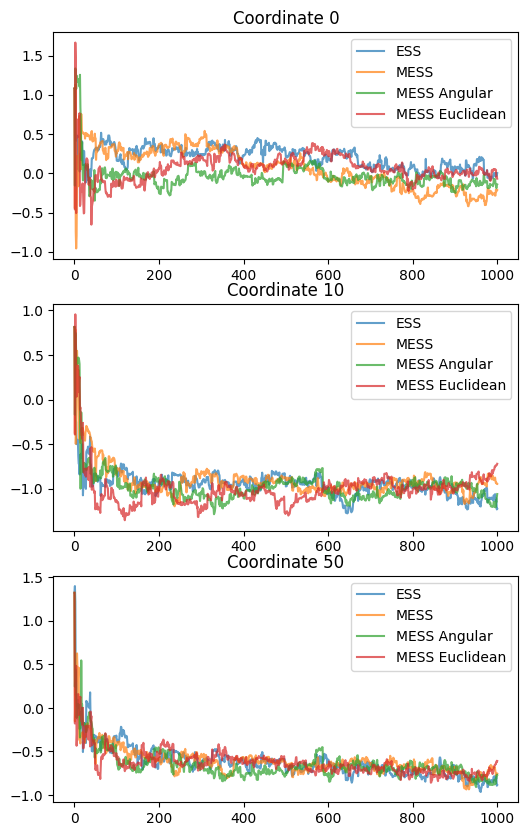

In [36]:
idx = [0, 10, 50]

fig, axes = plt.subplots(len(idx), 1, figsize=(6, 10))
for i, k in enumerate(idx):
    axes[i].plot(chain_ess[:, k], alpha=0.7, label="ESS")
    axes[i].plot(chain_mess[:, k], alpha=0.7, label="MESS")
    axes[i].plot(chain_mess_ang[:, k], alpha=0.7, label="MESS Angular")
    axes[i].plot(chain_mess_eucl[:, k], alpha=0.7, label="MESS Euclidean")
    axes[i].set_title(f"Coordinate {k}")
    axes[i].legend()

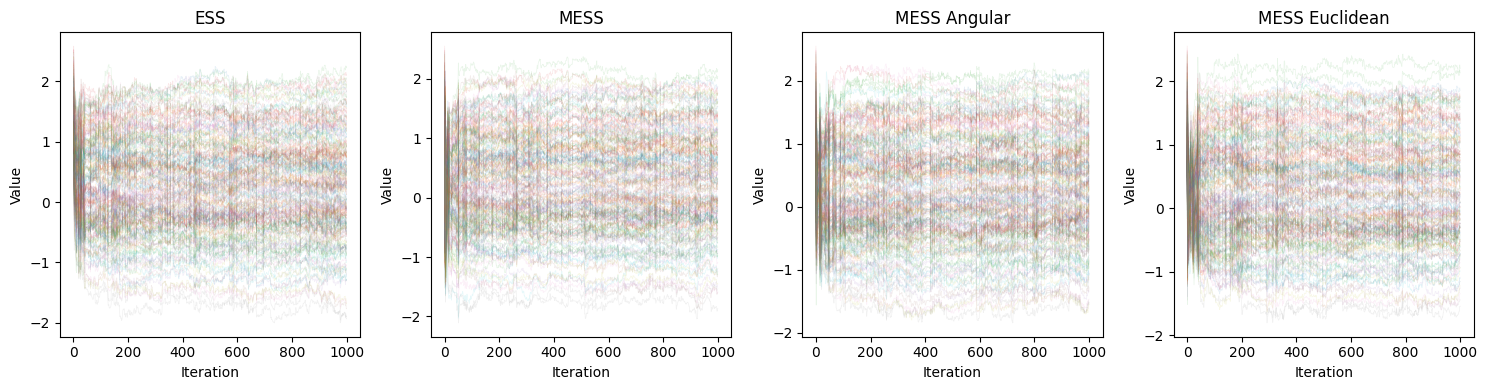

In [37]:
# Traceplot for all coordinates and algorithms at the same time
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

algorithms = [
    ("ESS", chain_ess[:]),
    ("MESS", chain_mess[:]),
    ("MESS Angular", chain_mess_ang[:]),
    ("MESS Euclidean", chain_mess_eucl[:]),
]

for idx, (algo_name, chain) in enumerate(algorithms):
    for k in range(num_data):
        axes[idx].plot(chain[:, k], alpha=0.1, linewidth=0.5)
    axes[idx].set_title(algo_name)
    axes[idx].set_xlabel("Iteration")
    axes[idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [38]:
f_true = data["f_true"]

samples_ess = chain_ess[burn_in + 1:]  # Skip initial state and burn_in
samples_mess = chain_mess[burn_in + 1:]
samples_mess_ang = chain_mess_ang[burn_in + 1:]
samples_mess_eucl = chain_mess_eucl[burn_in + 1:]

mean_ess = samples_ess.mean(axis=0)
mean_mess = samples_mess.mean(axis=0)
mean_mess_ang = samples_mess_ang.mean(axis=0)
mean_mess_eucl = samples_mess_eucl.mean(axis=0)

std_ess = samples_ess.std(axis=0)
std_mess = samples_mess.std(axis=0)
std_mess_ang = samples_mess_ang.std(axis=0)
std_mess_eucl = samples_mess_eucl.std(axis=0)

Text(0, 0.5, 'f')

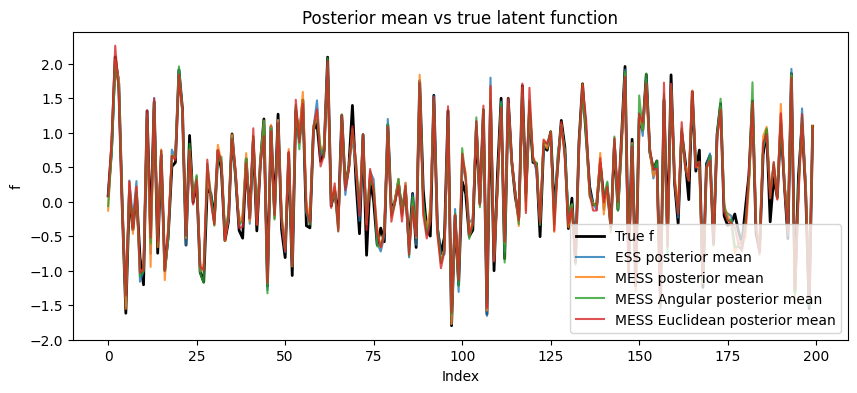

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(f_true, label="True f", color="black", linewidth=2)
plt.plot(mean_ess, label="ESS posterior mean", alpha=0.8)
plt.plot(mean_mess, label="MESS posterior mean", alpha=0.8)
plt.plot(mean_mess_ang, label="MESS Angular posterior mean", alpha=0.8)
plt.plot(mean_mess_eucl, label="MESS Euclidean posterior mean", alpha=0.8)
plt.legend()
plt.title("Posterior mean vs true latent function")
plt.xlabel("Index")
plt.ylabel("f")


Text(0.5, 1.0, 'Posterior mean error')

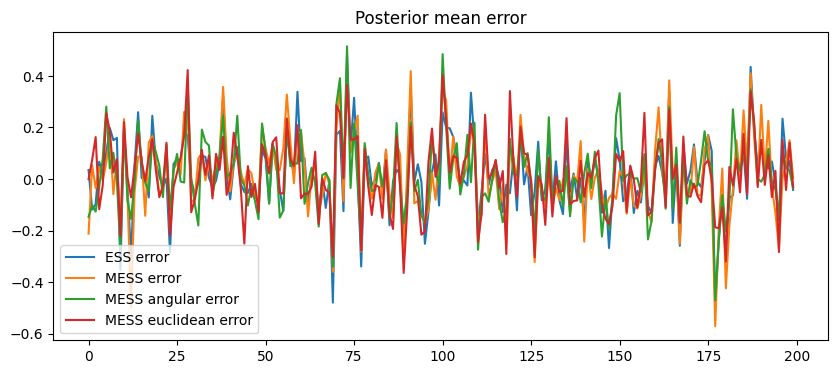

In [40]:
err_ess = mean_ess - f_true
err_mess = mean_mess - f_true
err_mess_ang = mean_mess_ang - f_true
err_mess_eucl = mean_mess_eucl - f_true

plt.figure(figsize=(10, 4))
plt.plot(err_ess, label="ESS error")
plt.plot(err_mess, label="MESS error")
plt.plot(err_mess_ang, label="MESS angular error")
plt.plot(err_mess_eucl, label="MESS euclidean error")
plt.legend()
plt.title("Posterior mean error")


In [41]:
rmse_ess = np.sqrt(np.mean(err_ess**2))
rmse_mess = np.sqrt(np.mean(err_mess**2))
rmse_mess_ang = np.sqrt(np.mean(err_mess_ang**2))
rmse_mess_eucl = np.sqrt(np.mean(err_mess_eucl**2))

print("RMSE ESS :", rmse_ess)
print("RMSE MESS:", rmse_mess)
print("RMSE MESS angular:", rmse_mess_ang)
print("RMSE MESS euclidean:", rmse_mess_eucl)


RMSE ESS : 0.14414481321409087
RMSE MESS: 0.15623206802075687
RMSE MESS angular: 0.14464956750978908
RMSE MESS euclidean: 0.14311780497574275


Text(0.5, 1.0, 'Standardized posterior error')

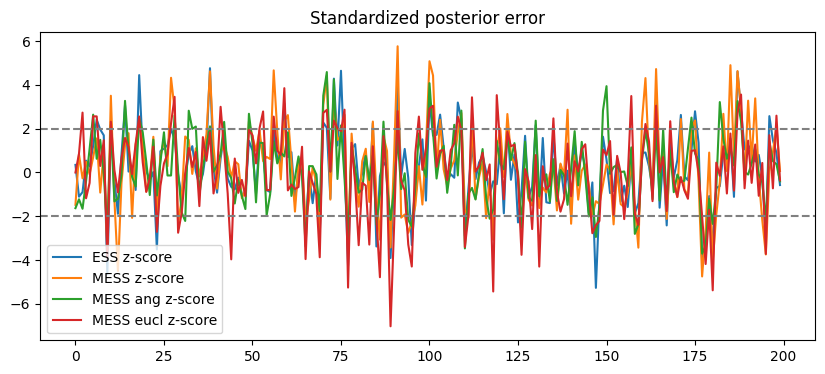

In [42]:
z_ess = (mean_ess - f_true) / std_ess
z_mess = (mean_mess - f_true) / std_mess
z_mess_ang = (mean_mess_ang - f_true) / std_mess_ang
z_mess_eucl = (mean_mess_eucl - f_true) / std_mess_eucl

plt.figure(figsize=(10, 4))
plt.plot(z_ess, label="ESS z-score")
plt.plot(z_mess, label="MESS z-score")
plt.plot(z_mess_ang, label="MESS ang z-score")
plt.plot(z_mess_eucl, label="MESS eucl z-score")
plt.axhline(2, color="gray", linestyle="--")
plt.axhline(-2, color="gray", linestyle="--")
plt.legend()
plt.title("Standardized posterior error")


In [44]:
# ESS
lower_ess = np.percentile(samples_ess, 2.5, axis=0)
upper_ess = np.percentile(samples_ess, 97.5, axis=0)

coverage_ess = np.mean(
    (f_true >= lower_ess) & (f_true <= upper_ess)
)

print("ESS 95% coverage:", coverage_ess)

# MESS
lower_mess = np.percentile(samples_mess, 2.5, axis=0)
upper_mess = np.percentile(samples_mess, 97.5, axis=0)
coverage_mess = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS 95% coverage:", coverage_mess)

# MESS angular
lower_mess = np.percentile(samples_mess_ang, 2.5, axis=0)
upper_mess = np.percentile(samples_mess_ang, 97.5, axis=0)
coverage_mess_ang = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS ang 95% coverage:", coverage_mess_ang)

# MESS euclidean
lower_mess = np.percentile(samples_mess_eucl, 2.5, axis=0)
upper_mess = np.percentile(samples_mess_eucl, 97.5, axis=0)
coverage_mess_eucl = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS eucl 95% coverage:", coverage_mess_eucl)

ESS 95% coverage: 0.785
MESS 95% coverage: 0.695
MESS ang 95% coverage: 0.735
MESS eucl 95% coverage: 0.665


Text(0.5, 1.0, 'Posterior mean vs observations')

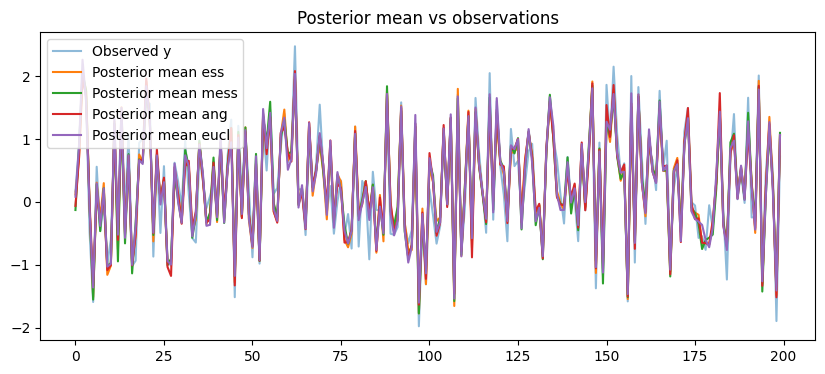

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(y, label="Observed y", alpha=0.5)
plt.plot(mean_ess, label="Posterior mean ess")
plt.plot(mean_mess, label="Posterior mean mess")
plt.plot(mean_mess_ang, label="Posterior mean ang")
plt.plot(mean_mess_eucl, label="Posterior mean eucl")
plt.legend()
plt.title("Posterior mean vs observations")


In [51]:
# Compute the effective sample size for each method
max_lag = 1200
ess_ess = estimate_effective_sample_size(chain_ess[burn_in + 1:, :], max_lag=max_lag)
ess_mess = estimate_effective_sample_size(chain_mess[burn_in + 1:, :], max_lag=max_lag)
ess_mess_ang = estimate_effective_sample_size(chain_mess_ang[burn_in + 1:, :], max_lag=max_lag)  
ess_mess_eucl = estimate_effective_sample_size(chain_mess_eucl[burn_in + 1:, :], max_lag=max_lag)

# Effective sample size per minute
percentage_useful_samples = (n_iters - burn_in) / n_iters
ess_minute_ess = ess_ess / (percentage_useful_samples * ess_time / 60.0)
ess_minute_mess = ess_mess / (percentage_useful_samples * mess_time / 60.0)
ess_minute_mess_ang = ess_mess_ang / (percentage_useful_samples * mess_ang_time / 60.0)
ess_minute_mess_eucl = ess_mess_eucl / (percentage_useful_samples * mess_eucl_time / 60.0)

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


/Users/guillers/Documents/GitHub/multiproposal/src/multiproposal/algorithms/effective_sample_size.py:93: RuntimeWarning: invalid value encountered in scalar divide
  acf[lag] = np.sum(x[lag:] * x[:-lag]) / ((N - lag) * variance)


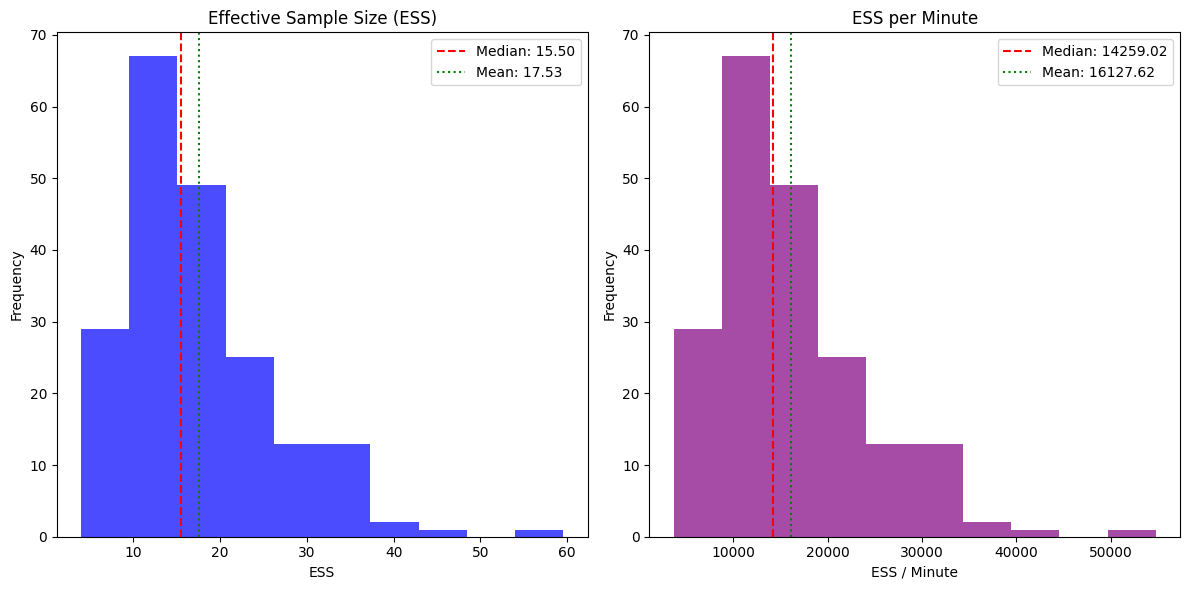

{'mean_ess': np.float64(17.5340895546423),
 'median_ess': np.float64(15.502534378636689),
 'mean_ess_per_minute': np.float64(16127.622365540341),
 'median_ess_per_minute': np.float64(14259.024934731468),
 'min_ess': np.float64(3.9937871498702973),
 'max_ess': np.float64(59.55233303465631),
 'min_ess_per_minute': np.float64(3673.432302300672),
 'max_ess_per_minute': np.float64(54775.44386760281)}

In [52]:
plot_ess_histograms(ess_ess, ess_minute_ess, figsize=(12, 6), 
                       parameter_names=None, bins=10)

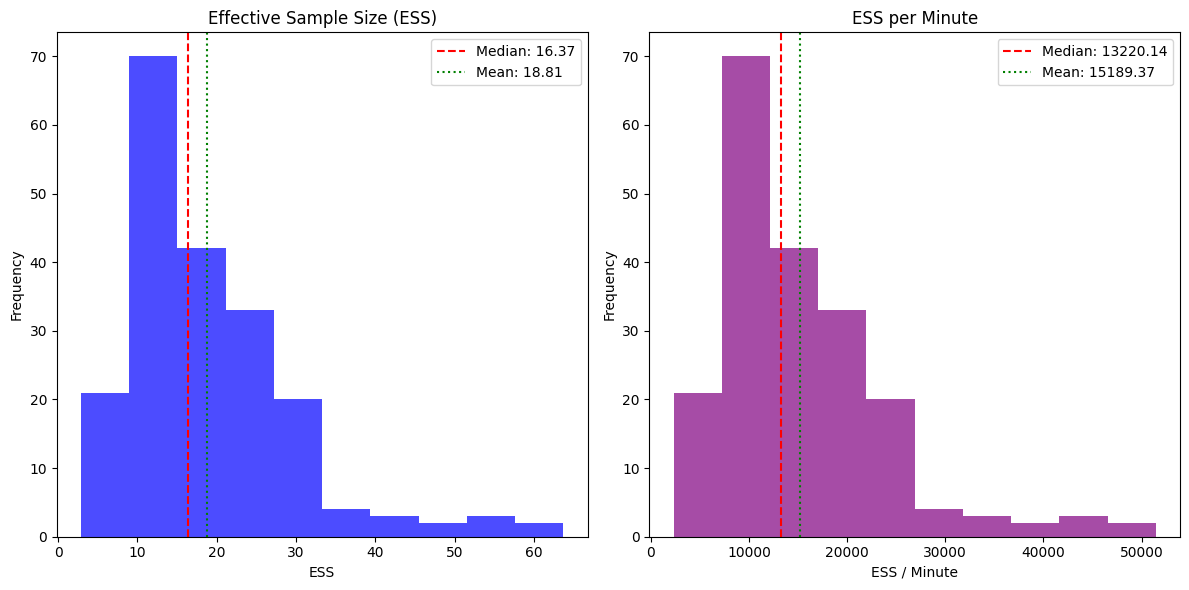

{'mean_ess': np.float64(18.81352782988141),
 'median_ess': np.float64(16.374442314301202),
 'mean_ess_per_minute': np.float64(15189.36842819851),
 'median_ess_per_minute': np.float64(13220.138156288162),
 'min_ess': np.float64(2.881271238469524),
 'max_ess': np.float64(63.71965394852497),
 'min_ess_per_minute': np.float64(2326.235184513041),
 'max_ess_per_minute': np.float64(51444.96602089757)}

In [53]:
plot_ess_histograms(ess_mess, ess_minute_mess, figsize=(12, 6), 
                       parameter_names=None, bins=10)

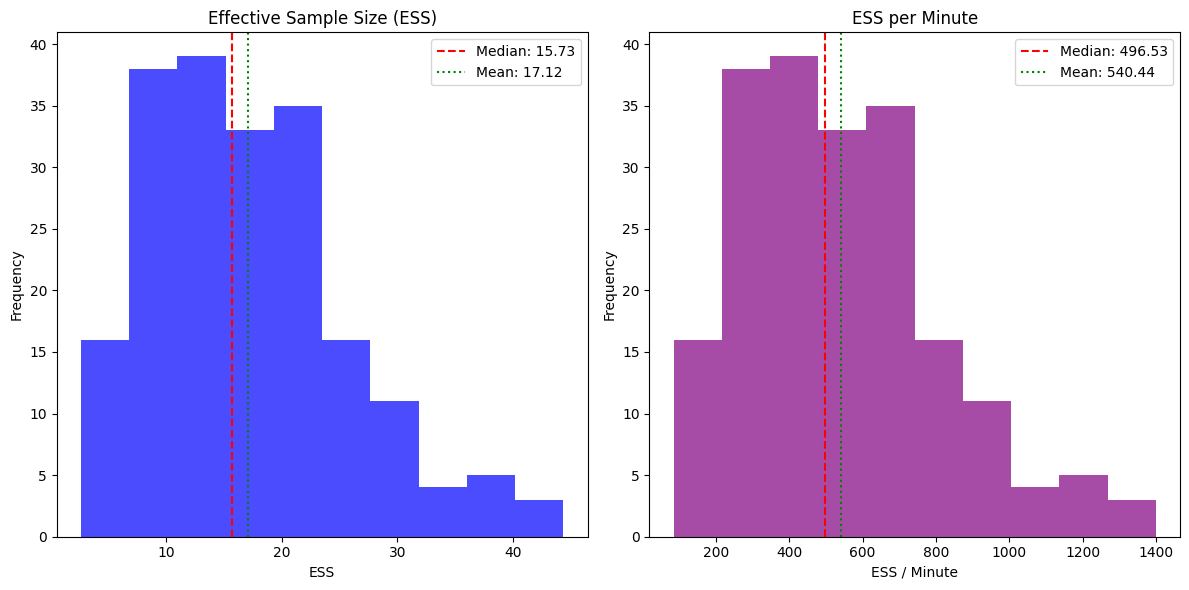

{'mean_ess': np.float64(17.12220924765211),
 'median_ess': np.float64(15.73098144004056),
 'mean_ess_per_minute': np.float64(540.4438850767423),
 'median_ess_per_minute': np.float64(496.5312946804132),
 'min_ess': np.float64(2.681661005499158),
 'max_ess': np.float64(44.33427433463125),
 'min_ess_per_minute': np.float64(84.64370872406563),
 'max_ess_per_minute': np.float64(1399.363079665188)}

In [54]:
plot_ess_histograms(ess_mess_ang, ess_minute_mess_ang, figsize=(12, 6), 
                       parameter_names=None, bins=10)

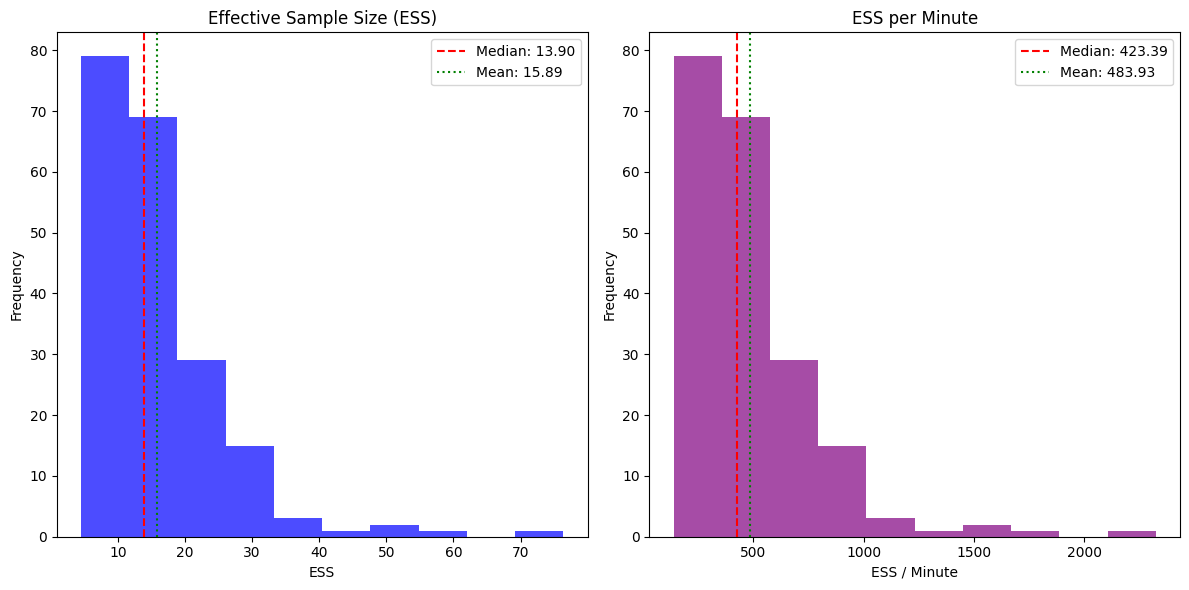

{'mean_ess': np.float64(15.892435364911776),
 'median_ess': np.float64(13.904293638625393),
 'mean_ess_per_minute': np.float64(483.93323065077146),
 'median_ess_per_minute': np.float64(423.3932425053667),
 'min_ess': np.float64(4.517869015561028),
 'max_ess': np.float64(76.38622032065982),
 'min_ess_per_minute': np.float64(137.57154886309056),
 'max_ess_per_minute': np.float64(2326.001618266372)}

In [55]:
plot_ess_histograms(ess_mess_eucl, ess_minute_mess_eucl, figsize=(12, 6), 
                       parameter_names=None, bins=10)